Loading Libraries

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


Data preperation

In [ ]:
df = pd.read_csv('Drought_Prediction.csv')
df.head(20)

,Unnamed: 0,district,year,month,rainfall_mm,SoilMoi_0_10,SoilMoi_10_40,SoilMoi_40_100,SoilMoi_100_200,et_mean_mm,...,soil_0_10_lag3,et_lag3,rainfall_roll3,rainfall_roll6,future_drought_class,target_1m_ahead,target_2m_ahead,target_3m_ahead,month_sin,month_cos
0,0,Ahmednagar,2015,6,127.566858,0.297236,0.297696,0.257036,0.349434,6.980997,...,0.157638,3.045763,51.386090,27.008090,No Drought,No Drought,No Drought,No Drought,1.224647e-16,-1.000000e+00
1,1,Ahmednagar,2015,7,52.172304,0.234076,0.321313,0.282012,0.352772,10.912704,...,0.173251,1.919723,67.984222,35.689121,No Drought,No Drought,No Drought,Moderate,-5.000000e-01,-8.660254e-01
2,2,Ahmednagar,2015,8,65.907127,0.283227,0.327283,0.296945,0.355740,15.930731,...,0.197919,1.985492,81.882096,46.662365,No Drought,No Drought,Moderate,Extreme,-8.660254e-01,-5.000000e-01
3,3,Ahmednagar,2015,9,211.699473,0.343166,0.356753,0.334319,0.365064,15.043684,...,0.297236,6.980997,109.926301,80.656196,No Drought,Moderate,Extreme,Extreme,-1.000000e+00,-1.836970e-16
4,4,Ahmednagar,2015,10,72.067995,0.289113,0.352400,0.357233,0.376176,9.686445,...,0.234076,10.912704,116.558199,92.271210,Moderate,Extreme,Extreme,Extreme,-8.660254e-01,5.000000e-01
5,5,Ahmednagar,2015,11,28.747276,0.231718,0.315782,0.322258,0.364618,7.825525,...,0.283227,15.930731,104.171582,93.026839,Extreme,Extreme,Extreme,Extreme,-5.000000e-01,8.660254e-01
6,6,Ahmednagar,2015,12,0.045454,0.198771,0.288359,0.292413,0.357824,4.214328,...,0.343166,15.043684,33.620242,71.773272,Extreme,Extreme,Extreme,No Drought,-2.449294e-16,1.000000e+00
7,7,Ahmednagar,2016,1,0.004455,0.159775,0.263094,0.267861,0.353344,2.802606,...,0.289113,9.686445,9.599062,63.078630,Extreme,Extreme,No Drought,No Drought,5.000000e-01,8.660254e-01
8,8,Ahmednagar,2016,2,1.242280,0.152059,0.248939,0.253355,0.350385,2.399675,...,0.231718,7.825525,0.430730,52.301156,Severe,No Drought,No Drought,No Drought,8.660254e-01,5.000000e-01
9,9,Ahmednagar,2016,3,3.732513,0.161982,0.242790,0.246408,0.348261,1.019703,...,0.198771,4.214328,1.659749,17.639996,No Drought,No Drought,No Drought,No Drought,1.000000e+00,6.123234e-17


In [ ]:
df = df.drop(df.filter(like="Unnamed:").columns, axis=1)

In [ ]:
target_columns = ['target_1m_ahead', 'target_2m_ahead', 'target_3m_ahead']

In [ ]:
features_exclude = ['future_drought_class', 'target_1m_ahead', 'target_2m_ahead', 'target_3m_ahead', 'month']
feature_columns = [col for col in df.columns if col not in features_exclude]

X = df[feature_columns]

In [ ]:
target = 'target_1m_ahead'
y = df[target]

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

Encoding

In [ ]:
#One hot encoding for districts
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_ohe = pd.DataFrame(
    ohe.fit_transform(X[['district']]),
    columns=ohe.get_feature_names_out(['district']),
    index=X.index
)

# replace district with OHE
X = pd.concat([X.drop(columns=['district']), X_ohe], axis=1)

Time_Series_Split

In [ ]:
train_year = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_year = [2022, 2023, 2024]

train_mask = df['year'].isin(train_year)
test_mask = df['year'].isin(test_year)

In [ ]:
X_train = X[train_mask]
X_test = X[test_mask]

y_1m_train = y[train_mask]
y_1m_test = y[test_mask]

In [ ]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("\nClass distribution in Training set:")
print(y_1m_train.value_counts())
print("\nClass distribution in Test set:")
print(y_1m_test.value_counts())

Training set shape: (2765, 69)
Test set shape: (1050, 69)

Class distribution in Training set:
target_1m_ahead
No Drought    1610
Extreme        877
Moderate       278
Name: count, dtype: int64

Class distribution in Test set:
target_1m_ahead
No Drought    732
Extreme       236
Moderate       82
Name: count, dtype: int64


In [ ]:
X.head(5)

,year,rainfall_mm,SoilMoi_0_10,SoilMoi_10_40,SoilMoi_40_100,SoilMoi_100_200,et_mean_mm,ndvi,mean_temp_c,ndvi_anomaly,...,district_Raigarh,district_Ratnagiri,district_Sangli,district_Satara,district_Sindhudurg,district_Solapur,district_Thane,district_Wardha,district_Washim,district_Yavatmal
0,2015,127.566858,0.297236,0.297696,0.257036,0.349434,6.980997,0.319885,39.880424,-0.880598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015,52.172304,0.234076,0.321313,0.282012,0.352772,10.912704,0.362202,37.587020,-0.507838,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015,65.907127,0.283227,0.327283,0.296945,0.355740,15.930731,0.387364,38.667298,-0.286192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015,211.699473,0.343166,0.356753,0.334319,0.365064,15.043684,0.447875,35.948097,0.246838,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015,72.067995,0.289113,0.352400,0.357233,0.376176,9.686445,0.481645,37.292949,0.544307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#computing class weights
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced',
                                                 classes=np.unique(y_1m_train),
                                                 y=y_1m_train)
class_weight_dict = dict(zip(np.unique(y_1m_train), class_weights))
print("\nClass Weights:", class_weight_dict)

# Create sample weights for the training data
sample_weights = y_1m_train.map(class_weight_dict)


Class Weights: {'Extreme': np.float64(1.0509312048650703), 'Moderate': np.float64(3.315347721822542), 'No Drought': np.float64(0.572463768115942)}


In [ ]:
# Label encoding target variable
le = LabelEncoder()
y_1m_train_encoded = le.fit_transform(y_1m_train)

Model training

In [ ]:
from xgboost import XGBClassifier
model_1m_xgb = XGBClassifier(random_state=42,
                         eval_metric='mlogloss',
                         use_label_encoder=False)

model_1m_xgb.fit(X_train, y_1m_train_encoded,
             sample_weight=sample_weights)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:51:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_1m_test_encoded = le.transform(y_1m_test)

In [ ]:
# Model testing
from sklearn.metrics import classification_report, confusion_matrix

# predictions on the test set
y_1m_pred_encoded = model_1m_xgb.predict(X_test)

# Converting predictions back to original labels for interpretation
y_1m_pred = le.inverse_transform(y_1m_pred_encoded)
print("Classification Report for 1-Month Model:\n")
print(classification_report(y_1m_test, y_1m_pred))
xgb_f1 = f1_score(y_1m_test, y_1m_pred, average="macro")

Classification Report for 1-Month Model:

              precision    recall  f1-score   support

     Extreme       0.81      0.86      0.83       236
    Moderate       0.34      0.39      0.36        82
  No Drought       0.94      0.91      0.92       732

    accuracy                           0.85      1050
   macro avg       0.70      0.72      0.71      1050
weighted avg       0.86      0.85      0.86      1050



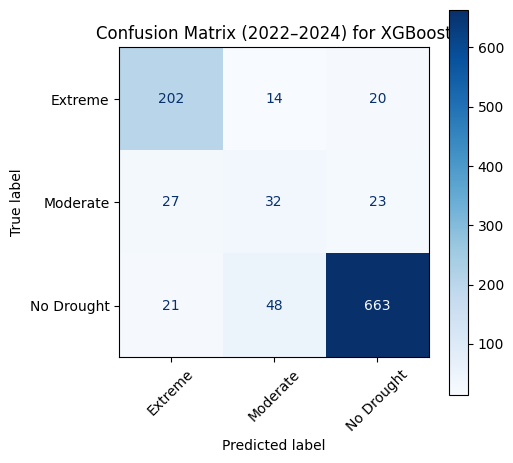

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_1m_test, y_1m_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix (2022–2024) for XGBoost")
plt.show()

Hyperparameter tuning

In [ ]:
param_dist_xgb = {
    "n_estimators": randint(200, 1200),
    "max_depth": randint(3, 15),
    "learning_rate": uniform(0.01, 0.3),   # continuous uniform [0.01, 0.31)
    "subsample": uniform(0.6, 0.4),        # [0.6, 1.0)
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
tscv = TimeSeriesSplit(n_splits=5)

random_search_xgb = RandomizedSearchCV(
    estimator=model_1m_xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_xgb.fit(X_train, y_1m_train_encoded, sample_weight=sample_weights)

print("Best Params:", random_search_xgb.best_params_)
print("Best CV Score:", random_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:55:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'colsample_bytree': np.float64(0.7760609974958406), 'gamma': np.float64(0.6101911742238941), 'learning_rate': np.float64(0.15855307303338106), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 1131, 'subsample': np.float64(0.672894435115225)}
Best CV Score: 0.7410480845651516


Tuned model

=== Tuned XGBoost Results on Test Set ===
              precision    recall  f1-score   support

     Extreme       0.80      0.78      0.79       236
    Moderate       0.28      0.43      0.34        82
  No Drought       0.94      0.90      0.92       732

    accuracy                           0.84      1050
   macro avg       0.68      0.70      0.68      1050
weighted avg       0.86      0.84      0.85      1050



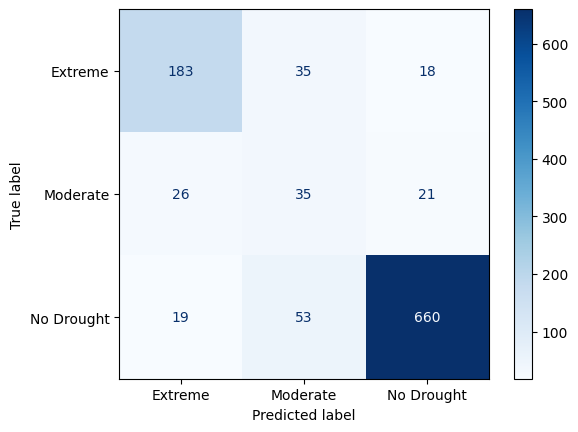

In [ ]:
# Best tuned model
best_xgb = random_search_xgb.best_estimator_

# Predictions on test data
y_test_pred = best_xgb.predict(X_test)

y_test_pred_labels = le.inverse_transform(y_test_pred)
y_test_labels = le.inverse_transform(y_1m_test_encoded)

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=== Tuned XGBoost Results on Test Set ===")
print(classification_report(y_test_labels, y_test_pred_labels, target_names=le.classes_))
xgb_tuned_f1 = f1_score(y_test_labels, y_test_pred_labels, average="macro")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_labels, y_test_pred_labels,
    display_labels=le.classes_,
    cmap="Blues"
)
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_1m_train_encoded)

print("Before SMOTE:", pd.Series(y_1m_train).value_counts())
print("After SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE: target_1m_ahead
No Drought    1610
Extreme        877
Moderate       278
Name: count, dtype: int64
After SMOTE:
 2    1610
1    1610
0    1610
Name: count, dtype: int64


In [ ]:
#Apply SMOTE to full training set (2015–2021)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_1m_train_encoded)

# Train RF on resampled set
model_xgb_smote = XGBClassifier(random_state=42,
                         eval_metric='mlogloss',
                         use_label_encoder=False)
model_xgb_smote.fit(X_train_resampled, y_train_resampled)

# Predict on hold-out test (2022–2024)
y_1m_pred_xgb_smote = model_xgb_smote.predict(X_test)

y_1m_pred_labels = le.inverse_transform(y_1m_pred_xgb_smote)
print(classification_report(y_1m_test, y_1m_pred_labels, target_names= le.classes_))
f1_smote_xgb = f1_score(y_1m_test, y_1m_pred_labels, average='macro')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:12:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

     Extreme       0.81      0.85      0.83       236
    Moderate       0.37      0.37      0.37        82
  No Drought       0.94      0.92      0.93       732

    accuracy                           0.86      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.86      0.86      0.86      1050



In [ ]:
from sklearn.metrics import classification_report

print("=== Baseline XGBoost ===")
print(classification_report(y_1m_test, y_1m_pred))

print("\n=== Tuned XGBoost ===")
print(classification_report(y_1m_test, y_test_pred_labels))

print("\n=== SMOTE XGBoost ===")
print(classification_report(y_1m_test, y_test_pred_labels))

# Calculate improvement
improvement = xgb_tuned_f1 - xgb_f1
print(f"\nF1 Score Improvement with hyperparameter tuning: {improvement:.4f} ({improvement*100:.2f}%)")

improvement = f1_smote_xgb - xgb_f1
print(f"\nF1 Score Improvement with smote: {improvement:.4f} ({improvement*100:.2f}%)")


=== Baseline XGBoost ===
              precision    recall  f1-score   support

     Extreme       0.81      0.86      0.83       236
    Moderate       0.34      0.39      0.36        82
  No Drought       0.94      0.91      0.92       732

    accuracy                           0.85      1050
   macro avg       0.70      0.72      0.71      1050
weighted avg       0.86      0.85      0.86      1050


=== Tuned XGBoost ===
              precision    recall  f1-score   support

     Extreme       0.80      0.78      0.79       236
    Moderate       0.28      0.43      0.34        82
  No Drought       0.94      0.90      0.92       732

    accuracy                           0.84      1050
   macro avg       0.68      0.70      0.68      1050
weighted avg       0.86      0.84      0.85      1050


=== SMOTE XGBoost ===
              precision    recall  f1-score   support

     Extreme       0.80      0.78      0.79       236
    Moderate       0.28      0.43      0.34        82
  No

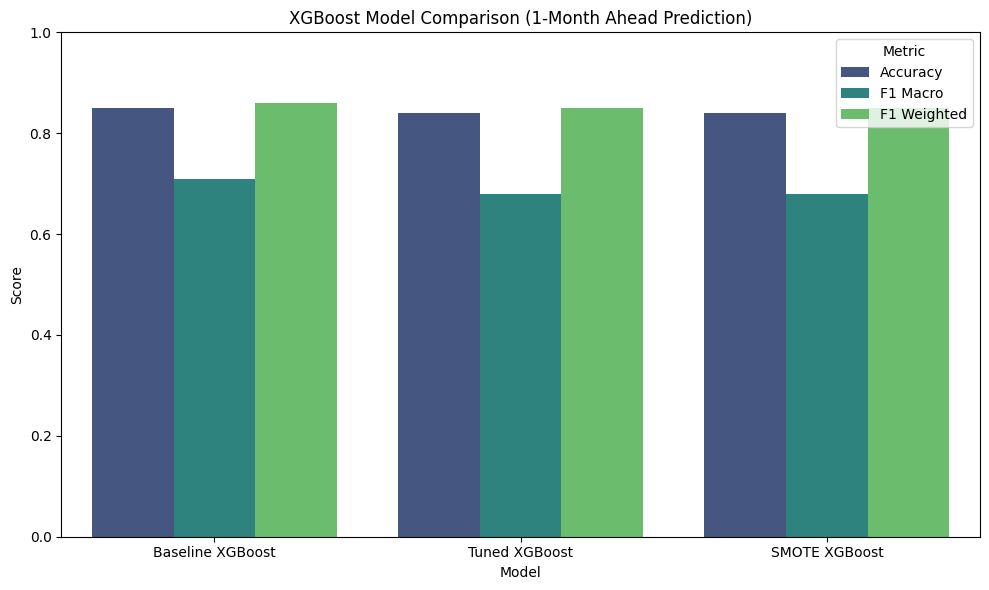

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Data preparation
# -----------------------------
models = ["Baseline XGBoost", "Tuned XGBoost", "SMOTE XGBoost"]
accuracy = [0.85, 0.84, 0.84]
f1_macro = [0.71, 0.68, 0.68]
f1_weighted = [0.86, 0.85, 0.85]

# Create a DataFrame for easier plotting
df_metrics = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "F1 Macro": f1_macro,
    "F1 Weighted": f1_weighted
})

# Melt the DataFrame for seaborn
df_melted = df_metrics.melt(id_vars="Model", 
                            value_vars=["Accuracy", "F1 Macro", "F1 Weighted"],
                            var_name="Metric", value_name="Score")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="viridis")

plt.title("XGBoost Model Comparison (1-Month Ahead Prediction)")
plt.ylim(0,1)
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()
